# jaxsedfit: SDSS J023335.37-010744.7 Joint SED + SDSS Spectrum Fit

This notebook uses Bandwagon to collect broadband photometry and discover SDSS spectra for SDSS J023335.37-010744.7, then fits both data sets with one `jaxsedfit` model. The joint model shares the host and AGN continuum with the spectroscopic likelihood, while the detailed spectral engine adds tied emission lines, Fe II, and Balmer continuum.


In [1]:
from pathlib import Path
import inspect
import sys

from astropy.coordinates import SkyCoord
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "jaxsedfit").is_dir():
    repo_root = repo_root.parent
bandwagon_root = repo_root.parent / "bandwagon"
jaxqsofit_root = repo_root.parent / "jaxqsofit"
src_roots = [repo_root / "src", bandwagon_root / "src", jaxqsofit_root / "src"]
for src_root in reversed(src_roots):
    src_path = str(src_root)
    if src_root.is_dir():
        sys.path[:] = [path for path in sys.path if path != src_path]
        sys.path.insert(0, src_path)

# Notebook kernels keep imported modules alive between edits. Drop local source
# packages so rerunning this cell always uses the sibling source trees above.
for module_name in list(sys.modules):
    if module_name == "bandwagon" or module_name.startswith("bandwagon."):
        del sys.modules[module_name]
    if module_name == "jaxsedfit" or module_name.startswith("jaxsedfit."):
        del sys.modules[module_name]
    if module_name == "jaxqsofit" or module_name.startswith("jaxqsofit."):
        del sys.modules[module_name]

import bandwagon
from bandwagon import matches_to_photometry, query_archival_spectra, xmatch_catalogs
from jaxsedfit.filters import load_filter_curves
from jaxsedfit import (
    AGNConfig,
    FilterSet,
    FitConfig,
    JAXSEDFit,
    GalaxyConfig,
    InferenceConfig,
    LikelihoodConfig,
    Observation,
    PhotometryData,
    SpectrumConfig,
    SpectroscopyData,
)

if "enrich_sdss_psf" not in inspect.signature(xmatch_catalogs).parameters:
    raise RuntimeError(
        "This notebook imported an older BandWagon without SDSS PSF enrichment. "
        "Restart the kernel or rerun this import cell. "
        f"Imported bandwagon from: {bandwagon.__file__}"
    )

print(f"Using bandwagon from: {bandwagon.__file__}")


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not import regions, which is required for some of the functionalities of this module.
Using bandwagon from: /Users/colinburke/research/bandwagon/src/bandwagon/__init__.py


In [2]:
candidate_ssp_files = [
    repo_root / "tempdata.h5",
    repo_root.parent / "jaxqsofit" / "tempdata.h5",
]
DSPS_SSP_FN = next((path for path in candidate_ssp_files if path.is_file()), None)
if DSPS_SSP_FN is None:
    raise FileNotFoundError(
        "No DSPS SSP file was found. Download tempdata.h5 as described in "
        "docs/installation.rst and place it in the jaxsedfit repository."
    )

TARGET_NAME = "J013453.20-001842.3"
coord = SkyCoord("01h34m53.20s", "-00d18m42.3s")
OBJECT_NAME = f"SDSS_{TARGET_NAME}"
print(f"Target: {OBJECT_NAME} at {coord.to_string('hmsdms')}")
print(f"DSPS SSP file: {DSPS_SSP_FN}")

Target: SDSS_J013453.20-001842.3 at 01h34m53.2s -00d18m42.3s
DSPS SSP file: /Users/colinburke/research/jaxqsofit/tempdata.h5


## Query Bandwagon Photometry


In [3]:
# BandWagon uses GALEX GR5 AUTO/Kron fluxes directly from CDS XMatch.
matches = xmatch_catalogs(coord, source_id=[OBJECT_NAME], cache=False)
for name, table in matches.items():
    print(f"{name}: {len(table)} matched rows")

sdss_table = matches.get("sdss_dr16")
if sdss_table is None or len(sdss_table) == 0:
    raise RuntimeError(
        "BandWagon did not return an SDSS DR16 match, so SDSS PSF photometry "
        "cannot appear in the SED plot. Check the XMatch result and match radius."
    )

required_psf_cols = {"upmag", "gpmag", "rpmag", "ipmag", "zpmag", "e_upmag", "e_gpmag", "e_rpmag", "e_ipmag", "e_zpmag"}
missing_psf_cols = sorted(required_psf_cols - set(sdss_table.colnames))
if missing_psf_cols:
    raise RuntimeError(
        "SDSS matched, but BandWagon did not enrich the XMatch result with PSF columns. "
        f"Missing columns: {missing_psf_cols}. "
        f"Imported bandwagon from: {bandwagon.__file__}"
    )

phot = matches_to_photometry(matches, max_mag_err=1.0)
phot = phot[np.isfinite(phot["flux_mjy"]) & np.isfinite(phot["flux_err_mjy"]) & (phot["flux_err_mjy"] > 0)]
if "speclite_name" in phot.colnames:
    phot.remove_column("speclite_name")
if "photometry_method" not in phot.colnames:
    raise RuntimeError("BandWagon must provide photometry_method so SDSS PSF photometry can be identified.")

sdss_filters = {f"{band}_sdss" for band in "ugriz"}
galex_filters = {"FUV_galex", "NUV_galex"}
found_galex = sorted(galex_filters & {str(name) for name in phot["filter_name"]})
if not found_galex:
    raise RuntimeError(
        "BandWagon matched GALEX but did not produce usable AUTO/Kron photometry."
    )

found_sdss = sorted(sdss_filters & {str(name) for name in phot["filter_name"]})
missing_sdss = sorted(sdss_filters - set(found_sdss))
if missing_sdss:
    raise RuntimeError(
        "BandWagon returned an SDSS match, but the long-form photometry table is missing "
        f"these SDSS PSF bands: {missing_sdss}. Available filters: "
        f"{[str(name) for name in phot['filter_name']]}"
    )

sdss_methods = {
    str(row["filter_name"]): str(row["photometry_method"])
    for row in phot
    if str(row["filter_name"]) in sdss_filters
}
if any(method != "psf" for method in sdss_methods.values()):
    raise RuntimeError(f"SDSS photometry must be PSF-only, got methods: {sdss_methods}")

galex_rows = phot[np.isin(phot["filter_name"], sorted(galex_filters))]
if any(str(method) != "auto" for method in galex_rows["photometry_method"]):
    raise RuntimeError("GALEX photometry must use BandWagon's AUTO/Kron measurements.")

print("BandWagon GALEX AUTO/Kron photometry:", found_galex)
print("BandWagon SDSS PSF photometry:", found_sdss)
phot.sort("match_distance_arcsec")
phot["catalog", "filter_name", "photometry_method", "flux_mjy", "flux_err_mjy", "psf_fwhm_arcsec", "match_distance_arcsec"]



galex_ais: 1 matched rows
sdss_dr16: 35 matched rows
2mass: 0 matched rows
allwise: 1 matched rows
legacy_dr8_north: 0 matched rows
legacy_dr8_south: 1 matched rows
BandWagon SDSS PSF photometry: ['g_sdss', 'i_sdss', 'r_sdss', 'u_sdss', 'z_sdss']


catalog,filter_name,photometry_method,flux_mjy,flux_err_mjy,psf_fwhm_arcsec,match_distance_arcsec
str9,str6,str7,float64,float64,float64,float64
sdss_dr16,g_sdss,psf,0.03168182924375816,0.0008103245443177369,1.44,0.053541
sdss_dr16,i_sdss,psf,0.0511717475777403,0.0016541449886567983,1.26,0.053541
sdss_dr16,r_sdss,psf,0.042236726255460745,0.0009022591254456196,1.32,0.053541
sdss_dr16,u_sdss,psf,0.021198359299526164,0.001214184622648176,1.53,0.053541
sdss_dr16,z_sdss,psf,0.07153823960134105,0.004220261567172738,1.29,0.053541
allwise,W1,profile,0.4152569175907143,0.012238904750366814,6.08,0.175146
allwise,W2,profile,0.498643463758343,0.016992901513255245,6.84,0.175146
allwise,W3,profile,1.1489548944163346,0.1259289641319666,7.36,0.175146
allwise,W4,profile,2.5844149782363774,0.9140483258456561,11.99,0.175146


## Query Bandwagon SDSS Spectra


In [4]:
spectra = query_archival_spectra(
    coord,
    source_id=[OBJECT_NAME],
    providers=("sdss",),
    radius_arcsec=5.0,
)
spectra.sort("redshift")
spectra[
    "provider",
    "release",
    "obs_id",
    "redshift",
    "quality",
    "sdss_plate",
    "sdss_mjd",
    "sdss_fiberid",
]

provider,release,obs_id,redshift,quality,sdss_plate,sdss_mjd,sdss_fiberid
str4,str4,str14,float64,str1,str4,str5,str3
sdss,dr17,698-52203-279,0.3036496,,698,52203,279
sdss,dr17,4230-55483-232,0.3037142,,4230,55483,232
sdss,dr17,697-52226-68,0.3038055,,697,52226,68


In [5]:
sdss_rows = spectra[spectra["provider"] == "sdss"]
if len(sdss_rows) == 0:
    raise RuntimeError(f"No SDSS spectrum was found for {OBJECT_NAME}.")

# Prefer rows with clean SDSS zwarning when available.
quality = np.asarray([str(q).strip() for q in sdss_rows["quality"]])
clean = np.flatnonzero((quality == "0") | (quality == ""))
row = sdss_rows[int(clean[0])] if clean.size else sdss_rows[0]

plate = int(row["sdss_plate"])
mjd = int(row["sdss_mjd"])
fiberid = int(row["sdss_fiberid"])
redshift = float(row["redshift"])
print(f"Using SDSS spectrum plate={plate}, mjd={mjd}, fiber={fiberid}, z={redshift:.5f}")

sdss_hdul = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberid)[0]
sdss_data = sdss_hdul[1].data
wave_obs = 10.0 ** np.asarray(sdss_data["loglam"], dtype=float)
flux_1e17 = np.asarray(sdss_data["flux"], dtype=float)
ivar = np.asarray(sdss_data["ivar"], dtype=float)
err_1e17 = np.full_like(ivar, np.nan, dtype=float)
positive_ivar = ivar > 0.0
err_1e17[positive_ivar] = 1.0 / np.sqrt(ivar[positive_ivar])

Using SDSS spectrum plate=698, mjd=52203, fiber=279, z=0.30365


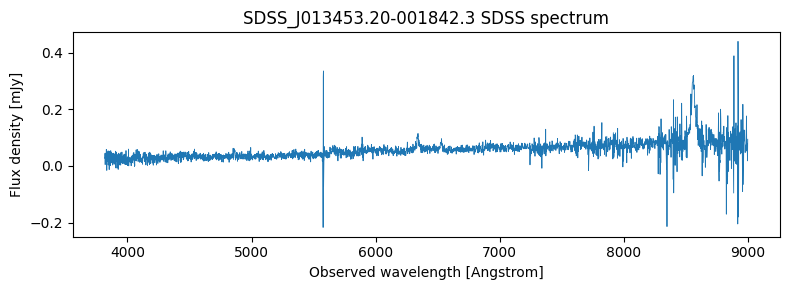

In [6]:
C_ANG_PER_S = 2.99792458e18

def flambda_1e17_to_mjy(wave_angstrom, flux_1e17):
    f_lambda_cgs = np.asarray(flux_1e17, dtype=float) * 1.0e-17
    f_nu_cgs = f_lambda_cgs * np.asarray(wave_angstrom, dtype=float) ** 2 / C_ANG_PER_S
    return f_nu_cgs / 1.0e-26


spec_flux_mjy = flambda_1e17_to_mjy(wave_obs, flux_1e17)
spec_err_mjy = flambda_1e17_to_mjy(wave_obs, err_1e17)
spec_mask = (
    np.isfinite(wave_obs)
    & np.isfinite(spec_flux_mjy)
    & np.isfinite(spec_err_mjy)
    & (spec_err_mjy > 0.0)
    & (wave_obs > 3600.0)
    & (wave_obs < 9000.0)
)

plt.figure(figsize=(8, 3))
plt.plot(wave_obs[spec_mask], spec_flux_mjy[spec_mask], lw=0.6)
plt.xlabel("Observed wavelength [Angstrom]")
plt.ylabel("Flux density [mJy]")
plt.title(f"{OBJECT_NAME} SDSS spectrum")
plt.tight_layout()

In [7]:
spec_wave_native = wave_obs[spec_mask]
spec_flux_native = spec_flux_mjy[spec_mask]
spec_err_native = spec_err_mjy[spec_mask]

print(f"Using {spec_wave_native.size:,} native SDSS spectral pixels")


Using 3,724 native SDSS spectral pixels


## Build A Joint Photometry + Spectrum Config


In [8]:
filter_names = [str(name) for name in phot["filter_name"]]
required_sdss_filters = {f"{band}_sdss" for band in "ugriz"}
missing_sdss_filters = sorted(required_sdss_filters - set(filter_names))
if missing_sdss_filters:
    raise RuntimeError(
        "The fit config is being built without SDSS PSF photometry. "
        f"Missing filters: {missing_sdss_filters}. Rerun the BandWagon photometry cell above."
    )

cfg = FitConfig(
    observation=Observation(
        object_id=f"{OBJECT_NAME}_joint",
        redshift=redshift,
        redshift_mode="fixed",
        ra=float(coord.ra.deg),
        dec=float(coord.dec.deg),
        apply_mw_deredden=True,
    ),
    photometry=PhotometryData(
        filter_names=filter_names,
        fluxes=[float(x) for x in phot["flux_mjy"]],
        errors=[float(x) for x in phot["flux_err_mjy"]],
        is_upper_limit=[False] * len(phot),
        psf_fwhm_arcsec=[float(x) if np.isfinite(x) else None for x in phot["psf_fwhm_arcsec"]],
        photometry_method=[str(x) for x in phot["photometry_method"]],
    ),
    filters=FilterSet(curves=load_filter_curves(filter_names)),
    spectroscopy=SpectroscopyData(
        wave_obs=spec_wave_native.tolist(),
        fluxes=spec_flux_native.tolist(),
        errors=spec_err_native.tolist(),
        mask=[True] * len(spec_wave_native),
        instrument="SDSS",
        aperture_diameter_arcsec=3.0,
        resolving_power=2000.0,
    ),
    galaxy=GalaxyConfig(
        dsps_ssp_fn=str(DSPS_SSP_FN),
        n_wave=512,
        rest_wave_min=100.0,
        rest_wave_max=3.0e6,
        fit_host_kinematics=True,
    ),
    agn=AGNConfig(
        agn_type=1,
        line_flux_scale_mjy=0.1,
    ),
    spectrum=SpectrumConfig(
        power_law_enabled=True,
        host_enabled=True,
        lines_enabled=True,
        tied_lines=True,
        feii_enabled=True,
        balmer_continuum_enabled=True,
    ),
    likelihood=LikelihoodConfig(
        use_host_capture_model=True,
        systematics_width=0.08,
        fit_spectrum_scale=True,
        spectrum_scale_prior_sigma_dex=0.1,
        spectrum_systematics_width=0.08,
        spectrum_student_t_df=5.0,
        spectrum_weight_mode="resolution_elements",
    ),
    inference=InferenceConfig(
        method="optax+nuts",
        map_steps=4000,
        learning_rate=5.0e-3,
        seed=3,
        num_warmup=200,
        num_samples=200,
        num_chains=1,
    ),
)
cfg.prior_config.agn.log_broad_line_width_kms = dist.TruncatedNormal(
    loc=np.log(3000.0),
    scale=0.4,
    low=np.log(1000.0),
    high=np.log(15000.0),
)
cfg.prior_config.agn.log_narrow_line_width_kms = dist.TruncatedNormal(
    loc=np.log(500.0),
    scale=0.3,
    low=np.log(100.0),
    high=np.log(1500.0),
)
cfg.validate()


## Fit

The fit runs staged MAP/SVI initialization followed by NUTS. The configured 200 warmup and 200 retained draws are suitable for demonstrating the workflow, but they are not a substitute for a longer, multi-chain run with convergence checks in scientific analysis. Use `cfg.inference.method = "optax"` while iterating quickly on the model and data choices.


In [ ]:
cfg.output.plot_fig = False
cfg.output.save_fig = False
cfg.output.save_result = False
cfg.output.plot_init = True
fitter = JAXSEDFit(cfg)
result = fitter.fit(progress_bar=True)


In [ ]:
prediction = result.predict(n_draws=200)
spectrum = prediction.spectrum
sdss = spectrum.observations[0]

print("Spectrum instrument:", sdss.instrument)
print("Posterior model shape (draw, pixel):", sdss.model_flux_mjy.shape)
print("Named line components:", sorted(spectrum.lines))
print("Named physical line groups:", sorted(spectrum.line_groups))

In [ ]:
fig = fitter.plot_spectrum(
    spectrum_index=0,
    show_plot=True,
    plot_residual=True,
    plot_legend=True,
)

In [ ]:
fitter.plot_sed(annotate_band_names=True)


In [ ]:
import numpy as np
from jaxsedfit import plot_corner

# Convert log-sampled positive parameters to their physical values.
corner_samples = {
    "pl_slope": np.asarray(result.samples["pl_slope"]),
    "ebv_gal": np.exp(np.asarray(result.samples["log_ebv_gal"])),
    "ebv_agn": np.exp(np.asarray(result.samples["log_ebv_agn"])),
    "log_stellar_mass": np.asarray(result.samples["log_stellar_mass"]),
    "fcov": np.asarray(result.samples["fcov"]),
    "si": np.asarray(result.samples["si"]),
    "cool_lam": np.asarray(result.samples["cool_lam"]),
    "cool_width": np.asarray(result.samples["cool_width"]),
    "hot_lam": np.asarray(result.samples["hot_lam"]),
    "hot_width": np.asarray(result.samples["hot_width"]),
    "hot_fcov": np.exp(np.asarray(result.samples["log_hot_fcov"])),
}

labels = {
    "pl_slope": r"$\alpha_{\rm AGN}$",
    "ebv_gal": r"$E(B-V)_{\rm host}$",
    "ebv_agn": r"$E(B-V)_{\rm AGN}$",
    "log_stellar_mass": r"$\log_{10}(M_\star/M_\odot)$",
    "fcov": r"$f_{\rm cov}$",
    "si": r"$S_{\rm sil}$",
    "cool_lam": r"$\lambda_{\rm cool}\;[\mu{\rm m}]$",
    "cool_width": r"$w_{\rm cool}$",
    "hot_lam": r"$\lambda_{\rm hot}\;[\mu{\rm m}]$",
    "hot_width": r"$w_{\rm hot}$",
    "hot_fcov": r"$f_{\rm hot}$",
}

fig = plot_corner(
    corner_samples,
    params=list(corner_samples),
    labels=labels,
    max_params=None,
    show=True,
    figsize=(16, 16),
)